In [49]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

In [50]:

PATHS = {
    'M0': '../output/results/M0_results.csv',
    'M1': '../output/results/M1_results.csv',
    'M2': '../output/results/M2_results.csv',
}

# Adjust these to match your data
DATE_COL = 'date'
COUNTRY_COL = 'country'
DD_COL = 'distance_to_distress'
CDS_COL = 'cds_spread'

# Horizons in weeks for computing changes
HORIZONS = [1, 2, 4, 8]

# Define your groups — edit these lists to match your sample
EXPORTERS = [
    'Saudi Arabia',
    'Abu Dhabi',
    'Qatar',
    'Colombia',
    'Mexico',
    'Brazil',
    'Egypt',
    'Malaysia']

CONTROLS = ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa', 'South Korea', 'Thailand', 'Turkey']

In [51]:
# ──────────────────────────────────────────────────────────────
# 2. LOAD DATA
# ──────────────────────────────────────────────────────────────

def load_models(paths):
    dfs = {}
    for m, p in paths.items():
        df = pd.read_csv(p, parse_dates=[DATE_COL])
        df = df.sort_values([COUNTRY_COL, DATE_COL])
        dfs[m] = df
    return dfs

dfs = load_models(PATHS)

# Auto-detect controls if not specified
all_countries = sorted(dfs['M0'][COUNTRY_COL].unique())
if CONTROLS is None:
    CONTROLS = [c for c in all_countries if c not in EXPORTERS]

print(f"Total countries: {len(all_countries)}")
print(f"Exporters ({len(EXPORTERS)}): {EXPORTERS}")
print(f"Controls  ({len(CONTROLS)}): {CONTROLS}")

Total countries: 17
Exporters (8): ['Saudi Arabia', 'Abu Dhabi', 'Qatar', 'Colombia', 'Mexico', 'Brazil', 'Egypt', 'Malaysia']
Controls  (8): ['Chile', 'China', 'Indonesia', 'Philippines', 'South Africa', 'South Korea', 'Thailand', 'Turkey']


In [33]:
def compute_changes(df, horizon_weeks):
    """Compute ΔDD and ΔCDS over a given horizon (in weeks)."""
    out = []
    for country, grp in df.groupby(COUNTRY_COL):
        g = grp.set_index(DATE_COL).sort_index()
        # Resample to weekly if daily data
        g = g[[DD_COL, CDS_COL]].resample('W').last().dropna()
        g[f'delta_dd'] = g[DD_COL].diff(horizon_weeks)
        g[f'delta_cds'] = g[CDS_COL].diff(horizon_weeks)
        g[COUNTRY_COL] = country
        out.append(g.dropna(subset=['delta_dd', 'delta_cds']).reset_index())
    if not out:
        return pd.DataFrame()
    return pd.concat(out, ignore_index=True)

# ──────────────────────────────────────────────────────────────
# 4. CORRELATION FUNCTIONS
# ──────────────────────────────────────────────────────────────

def pearson_corr(dd, cds):
    if len(dd) < 10:
        return np.nan
    return np.corrcoef(dd, cds)[0, 1]


def spearman_corr(dd, cds):
    if len(dd) < 10:
        return np.nan
    rho, _ = spearmanr(dd, cds)
    return rho


def country_correlations(df, corr_func):
    """Compute correlation per country, return Series."""
    results = {}
    for country, grp in df.groupby(COUNTRY_COL):
        dd = grp['delta_dd'].values
        cds = grp['delta_cds'].values
        mask = np.isfinite(dd) & np.isfinite(cds)
        if mask.sum() >= 10:
            results[country] = corr_func(dd[mask], cds[mask])
    return pd.Series(results)


def run_correlation_table(corr_func, corr_name):
    """
    Returns a DataFrame:
        rows = horizons
        columns = MultiIndex (model, group)
        values = mean correlation across countries in that group
    """
    records = []
    for h in HORIZONS:
        for m in PATHS.keys():
            changes = compute_changes(dfs[m], h)
            if changes.empty:
                continue
            corrs = country_correlations(changes, corr_func)

            all_mean = corrs.mean()
            exp_mean = corrs[corrs.index.isin(EXPORTERS)].mean()
            ctrl_mean = corrs[corrs.index.isin(CONTROLS)].mean()

            records.append({
                'horizon_w': h,
                'model': m,
                'all': all_mean,
                'exporters': exp_mean,
                'controls': ctrl_mean,
                'diff': exp_mean - ctrl_mean,
            })

    df_out = pd.DataFrame(records)
    df_out['corr_type'] = corr_name
    return df_out

In [34]:
pearson_results = run_correlation_table(pearson_corr, 'Pearson')
# Spearman
spearman_results = run_correlation_table(spearman_corr, 'Spearman')

results = pd.concat([pearson_results, spearman_results], ignore_index=True)


In [35]:
# 6. DISPLAY TABLES
# ──────────────────────────────────────────────────────────────

def display_table(df, corr_name, group_col, title):
    subset = df[df['corr_type'] == corr_name]
    pivot = subset.pivot_table(index='horizon_w', columns='model', values=group_col)
    pivot = pivot[list(PATHS.keys())]  # enforce column order
    pivot.index.name = 'Horizon (weeks)'
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  {corr_name} correlation — average across countries")
    print(f"{'='*60}")
    print(pivot.round(3).to_string())
    return pivot


# Table 1: Pearson, all countries
t1 = display_table(results, 'Pearson', 'all',
                    'Pearson — All Countries')

# Table 2: Pearson, exporters vs controls
t2_exp = display_table(results, 'Pearson', 'exporters',
                        'Pearson — Exporters')
t2_ctrl = display_table(results, 'Pearson', 'controls',
                         'Pearson — Controls')

# Table 3: Spearman, exporters vs controls
t3_exp = display_table(results, 'Spearman', 'exporters',
                        'Spearman — Exporters')
t3_ctrl = display_table(results, 'Spearman', 'controls',
                         'Spearman — Controls')


  Pearson — All Countries
  Pearson correlation — average across countries
model               M0     M1     M2
Horizon (weeks)                     
1               -0.064 -0.162 -0.154
2               -0.088 -0.205 -0.210
4               -0.112 -0.240 -0.266
8               -0.131 -0.300 -0.311

  Pearson — Exporters
  Pearson correlation — average across countries
model               M0     M1     M2
Horizon (weeks)                     
1               -0.077 -0.170 -0.169
2               -0.107 -0.228 -0.224
4               -0.143 -0.274 -0.288
8               -0.164 -0.336 -0.325

  Pearson — Controls
  Pearson correlation — average across countries
model               M0     M1     M2
Horizon (weeks)                     
1               -0.055 -0.143 -0.143
2               -0.077 -0.172 -0.199
4               -0.090 -0.194 -0.239
8               -0.107 -0.252 -0.289

  Spearman — Exporters
  Spearman correlation — average across countries
model               M0     M1     M2
Hori

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import rankdata
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
# NEWEY-WEST CORRELATION TEST
# Regress delta_cds on delta_dd with HAC SE, lag = horizon - 1
# For Spearman: rank-transform both series first
# Returns: coef, t-stat, p-value, n
# ──────────────────────────────────────────────────────────────

def nw_corr_test(dd, cds, horizon, spearman=False):
    """
    Tests whether the correlation between dd and cds changes is
    significantly different from zero, accounting for overlap.
    
    NW lag = horizon - 1 (covers exactly the overlapping window).
    For Spearman: rank-transforms both series before regression.
    Returns (correlation, t_stat, p_value, n_obs)
    """
    mask = np.isfinite(dd) & np.isfinite(cds)
    dd, cds = dd[mask], cds[mask]
    n = len(dd)
    if n < 10:
        return np.nan, np.nan, np.nan, n

    if spearman:
        x = rankdata(dd).astype(float)
        y = rankdata(cds).astype(float)
        # Normalize ranks to [-1, 1] so slope ≈ Spearman rho
        x = (x - x.mean()) / x.std(ddof=1)
        y = (y - y.mean()) / y.std(ddof=1)
    else:
        x = (dd - dd.mean()) / dd.std(ddof=1)
        y = (cds - cds.mean()) / cds.std(ddof=1)

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': max(1, horizon - 1), 'use_correction': True}
    )
    coef  = model.params[1]        # slope = correlation (standardized)
    tstat = model.tvalues[1]
    pval  = model.pvalues[1]
    return coef, tstat, pval, n


# ──────────────────────────────────────────────────────────────
# COUNTRY-LEVEL RESULTS WITH NW TESTS
# ──────────────────────────────────────────────────────────────

def country_nw_results(df, horizon, spearman=False):
    """Returns DataFrame with one row per country: corr, t, p, n."""
    rows = []
    for country, grp in df.groupby(COUNTRY_COL):
        dd  = grp['delta_dd'].values
        cds = grp['delta_cds'].values
        coef, tstat, pval, n = nw_corr_test(dd, cds, horizon, spearman=spearman)
        rows.append({
            COUNTRY_COL: country,
            'corr': coef,
            'tstat': tstat,
            'pval': pval,
            'n': n
        })
    return pd.DataFrame(rows).set_index(COUNTRY_COL)


# ──────────────────────────────────────────────────────────────
# AGGREGATE TABLE WITH SE BANDS
# Group mean + bootstrap SE across countries (accounts for
# cross-sectional sampling uncertainty in the group average)
# ──────────────────────────────────────────────────────────────

def bootstrap_mean_ci(corrs, n_boot=2000, ci=0.95):
    """Bootstrap CI for the mean of a small group of correlations."""
    corrs = corrs.dropna().values
    if len(corrs) < 2:
        return np.nan, np.nan
    boot = [np.mean(np.random.choice(corrs, size=len(corrs), replace=True))
            for _ in range(n_boot)]
    lo = np.percentile(boot, 100*(1-ci)/2)
    hi = np.percentile(boot, 100*(1+ci)/2)
    return lo, hi


def run_nw_table(spearman=False):
    """
    Builds the full results table with NW-adjusted correlations,
    country-level significance, and bootstrapped group CIs.
    """
    corr_label = 'Spearman' if spearman else 'Pearson'
    records = []

    for h in HORIZONS:
        for m in PATHS.keys():
            changes = compute_changes(dfs[m], h)
            if changes.empty:
                continue

            country_res = country_nw_results(changes, h, spearman=spearman)
            country_res['group'] = country_res.index.map(
                lambda c: 'exporter' if c in EXPORTERS
                          else ('control' if c in CONTROLS else 'other')
            )

            for grp_name, grp_countries in [('all', EXPORTERS + CONTROLS),
                                             ('exporters', EXPORTERS),
                                             ('controls', CONTROLS)]:
                subset = country_res[country_res.index.isin(grp_countries)]
                mean_corr = subset['corr'].mean()
                lo, hi = bootstrap_mean_ci(subset['corr'])
                n_sig = (subset['pval'] < 0.10).sum()  # country-level sig at 10%

                records.append({
                    'horizon_w': h,
                    'model': m,
                    'group': grp_name,
                    'corr': mean_corr,
                    'ci_lo': lo,
                    'ci_hi': hi,
                    'n_sig_10pct': n_sig,
                    'n_countries': len(subset),
                    'corr_type': corr_label,
                })

    return pd.DataFrame(records)


np.random.seed(42)
nw_pearson  = run_nw_table(spearman=False)
nw_spearman = run_nw_table(spearman=True)
nw_results  = pd.concat([nw_pearson, nw_spearman], ignore_index=True)


# ──────────────────────────────────────────────────────────────
# DISPLAY
# ──────────────────────────────────────────────────────────────

def display_nw_table(df, corr_name, group_col, title):
    subset = df[(df['corr_type'] == corr_name) & (df['group'] == group_col)]
    print(f"\n{'='*70}")
    print(f"  {title} | NW-adjusted (lag = horizon - 1) | 95% bootstrap CI")
    print(f"{'='*70}")
    print(f"{'Horizon':>10} {'Model':>6} {'Corr':>8} {'95% CI':>18} {'N sig (10%)':>12}")
    print(f"{'-'*70}")
    for _, row in subset.sort_values(['horizon_w','model']).iterrows():
        print(f"{row['horizon_w']:>10}w {row['model']:>6} "
              f"{row['corr']:>8.3f} "
              f"[{row['ci_lo']:>6.3f}, {row['ci_hi']:>6.3f}] "
              f"{int(row['n_sig_10pct']):>6}/{int(row['n_countries'])}")


display_nw_table(nw_results, 'Spearman', 'exporters', 'Spearman — Exporters')
display_nw_table(nw_results, 'Spearman', 'controls',  'Spearman — Controls')
display_nw_table(nw_results, 'Pearson',  'exporters', 'Pearson  — Exporters')
display_nw_table(nw_results, 'Pearson',  'controls',  'Pearson  — Controls')


  Spearman — Exporters | NW-adjusted (lag = horizon - 1) | 95% bootstrap CI
   Horizon  Model     Corr             95% CI  N sig (10%)
----------------------------------------------------------------------
         1w     M0   -0.120 [-0.216, -0.025]      6/8
         1w     M1   -0.151 [-0.228, -0.078]      5/8
         1w     M2   -0.233 [-0.290, -0.176]      8/8
         2w     M0   -0.132 [-0.218, -0.049]      4/8
         2w     M1   -0.136 [-0.206, -0.070]      5/8
         2w     M2   -0.275 [-0.326, -0.220]      8/8
         4w     M0   -0.134 [-0.216, -0.049]      4/8
         4w     M1   -0.144 [-0.202, -0.088]      5/8
         4w     M2   -0.304 [-0.364, -0.231]      7/8
         8w     M0   -0.147 [-0.223, -0.068]      4/8
         8w     M1   -0.168 [-0.234, -0.105]      6/8
         8w     M2   -0.324 [-0.388, -0.257]      8/8

  Spearman — Controls | NW-adjusted (lag = horizon - 1) | 95% bootstrap CI
   Horizon  Model     Corr             95% CI  N sig (10%)
----------

In [37]:
# ──────────────────────────────────────────────────────────────
# PER-COUNTRY CORRELATION TABLES
# Rows = countries (exporters first, then controls)
# Columns = M0 / M1 / M2
# One table per (correlation type × horizon)
# ──────────────────────────────────────────────────────────────

def per_country_table(horizon, spearman=False, nw=False):
    """
    Returns a DataFrame with countries as rows and models as columns.
    Values are NW-adjusted (if nw=True) or simple correlations.
    Countries ordered: exporters first, then controls.
    Significance stars added to NW estimates (*** p<0.01, ** p<0.05, * p<0.10).
    """
    corr_func = spearman_corr if not nw else None
    country_order = [c for c in EXPORTERS if c in all_countries] + \
                    [c for c in CONTROLS  if c in all_countries]

    model_cols = {}
    for m in PATHS.keys():
        changes = compute_changes(dfs[m], horizon)
        if changes.empty:
            model_cols[m] = pd.Series(dtype=float)
            continue

        if nw:
            res = country_nw_results(changes, horizon, spearman=spearman)
            # Format: value + stars
            def fmt(row):
                if pd.isna(row['corr']):
                    return '—'
                stars = '***' if row['pval'] < 0.01 else ('**' if row['pval'] < 0.05 else ('*' if row['pval'] < 0.10 else ''))
                return f"{row['corr']:.3f}{stars}"
            model_cols[m] = res.apply(fmt, axis=1)
        else:
            corrs = country_correlations(changes, spearman_corr if spearman else pearson_corr)
            model_cols[m] = corrs.round(3)

    table = pd.DataFrame(model_cols)
    # Reindex to enforce country order, keeping only present countries
    present = [c for c in country_order if c in table.index]
    table = table.reindex(present)

    # Add group separator label
    table.index = pd.Index([
        c + (" [E]" if c in EXPORTERS else " [C]") for c in present
    ], name='Country')

    return table


def display_per_country_table(horizon, spearman=False, nw=False):
    corr_name = 'Spearman' if spearman else 'Pearson'
    nw_note   = ' (NW-adjusted, * p<0.10, ** p<0.05, *** p<0.01)' if nw else ''
    print(f"\n{'='*65}")
    print(f"  {corr_name} per country — {horizon}w horizon{nw_note}")
    print(f"  [E] = Oil Exporter  |  [C] = Control")
    print(f"{'='*65}")
    tbl = per_country_table(horizon, spearman=spearman, nw=nw)
    print(tbl.to_string())
    print()
    return tbl


# ── Simple correlations (all horizons, both metrics) ──────────
print("\n" + "▓"*65)
print("  SIMPLE CORRELATIONS — PER COUNTRY")
print("▓"*65)
for h in HORIZONS:
    display_per_country_table(h, spearman=False, nw=False)
for h in HORIZONS:
    display_per_country_table(h, spearman=True,  nw=False)

# ── NW-adjusted with significance stars ───────────────────────
print("\n" + "▓"*65)
print("  NW-ADJUSTED CORRELATIONS — PER COUNTRY")
print("▓"*65)
for h in HORIZONS:
    display_per_country_table(h, spearman=False, nw=True)
for h in HORIZONS:
    display_per_country_table(h, spearman=True,  nw=True)



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SIMPLE CORRELATIONS — PER COUNTRY
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Pearson per country — 1w horizon
  [E] = Oil Exporter  |  [C] = Control
                     M0     M1     M2
Country                              
Saudi Arabia [E]  0.003 -0.092 -0.096
Abu Dhabi [E]     0.008 -0.127 -0.180
Qatar [E]         0.004 -0.136 -0.164
Colombia [E]     -0.120 -0.203 -0.169
Mexico [E]       -0.281 -0.306 -0.278
Brazil [E]       -0.209 -0.281 -0.224
Egypt [E]         0.003 -0.013 -0.033
Malaysia [E]     -0.023 -0.199 -0.205
Chile [C]        -0.059 -0.205 -0.139
China [C]         0.005 -0.078  0.019
Indonesia [C]    -0.011 -0.115 -0.183
Philippines [C]  -0.000 -0.104 -0.198
South Africa [C] -0.251 -0.238 -0.205
South Korea [C]  -0.018 -0.069 -0.157
Thailand [C]      0.004 -0.152 -0.173
Turkey [C]       -0.110 -0.185 -0.106


  Pearson per country — 2w horizon
  [E] = Oil Exporter  |  [C] = Cont

In [43]:
REGIMES = {
    # --- EXISTING ---
    'High OVX\n(Mar–Apr 2020)': {
        'start': '2020-02-17',
        'end':   '2020-04-30',
        'description': 'COVID demand collapse. OVX peak ~320.',
        'type': 'demand_shock'
    },
    'Backwardation\n(Jun–Dec 2021)': {
        'start': '2021-06-01',
        'end':   '2021-12-31',
        'description': 'Post-COVID recovery. Spot > futures.',
        'type': 'backwardation'
    },
    'Contango\n(Apr–Jun 2020)': {
        'start': '2020-04-01',
        'end':   '2020-06-30',
        'description': 'Storage glut. Futures > spot.',
        'type': 'contango'
    },
    'Supply Shock\n(Feb–May 2022)': {
        'start': '2022-02-01',
        'end':   '2022-05-31',
        'description': 'Russia invasion. Supply disruption.',
        'type': 'geopolitical'
    },
    'Demand Crash\n(Oct–Dec 2018)': {
        'start': '2018-10-01',
        'end':   '2018-12-31',
        'description': 'Demand-driven price collapse.',
        'type': 'demand_shock'
    },
    'Oversupply\n(Jul 2015–Jan 2016)': {
        'start': '2015-07-01',
        'end':   '2016-01-31',
        'description': 'Prolonged oversupply. Persistent contango.',
        'type': 'contango'
    },
    # --- NEW ---
    'OPEC+ Deal\n(Nov 2016–Jun 2017)': {
        'start': '2016-11-01',
        'end':   '2017-06-30',
        'description': 'First OPEC+ cut agreement. Contango to backwardation.',
        'type': 'policy_backwardation'
    },
    'Trade War\n(Aug–Oct 2019)': {
        'start': '2019-08-01',
        'end':   '2019-10-31',
        'description': 'US-China trade war. Demand fears. Moderate OVX.',
        'type': 'demand_shock'
    },
    'Iran Sanctions\n(May–Aug 2018)': {
        'start': '2018-05-01',
        'end':   '2018-08-31',
        'description': 'US reimposed Iran sanctions. Supply risk backwardation.',
        'type': 'geopolitical_backwardation'
    },
    'OPEC+ Cuts\n(Apr–Dec 2023)': {
        'start': '2023-04-01',
        'end':   '2023-12-31',
        'description': 'Voluntary Saudi-led production cuts.',
        'type': 'policy_backwardation'
    },
    'Post-Invasion High\n(Jun–Dec 2022)': {
        'start': '2022-06-01',
        'end':   '2022-12-31',
        'description': 'Sustained elevated prices post-invasion.',
        'type': 'supply_shock'
    },
    'COVID Recovery\n(Jan–May 2021)': {
        'start': '2021-01-01',
        'end':   '2021-05-31',
        'description': 'Vaccine rollout. Demand surge expectations.',
        'type': 'backwardation'
    },
    'China Reopening\n(Dec 2022–Mar 2023)': {
        'start': '2022-12-01',
        'end':   '2023-03-31',
        'description': 'China zero-COVID exit. Demand surge expectations.',
        'type': 'demand_pull'
    },
}

# ──────────────────────────────────────────────────────────────
# PER-COUNTRY REGIME CORRELATION TABLE
# Spearman correlation (ΔDD vs ΔCDS) for M0 / M1 / M2
# for each country × each regime window
# Contemporaneous (1-week changes)
# ──────────────────────────────────────────────────────────────

def spearman_corr_country(changes_df, country):
    """Spearman correlation for a single country."""
    subset = changes_df[changes_df[COUNTRY_COL] == country]
    dd  = subset['delta_dd'].values
    cds = subset['delta_cds'].values
    mask = np.isfinite(dd) & np.isfinite(cds)
    if mask.sum() < 5:
        return np.nan
    rho, _ = spearmanr(dd[mask], cds[mask])
    return rho


def per_country_regime_table(regime_label, regime_info):
    """
    For a given regime, compute M0/M1/M2 Spearman correlation
    for every country, and the improvement over M0.
    Returns a DataFrame sorted by M2 improvement.
    """
    results = {}
    for model in ['M0', 'M1', 'M2']:
        changes = compute_changes_filtered(
            dfs[model],
            1,  # contemporaneous
            regime_info['start'],
            regime_info['end']
        )
        country_corrs = {}
        for country in EXPORTERS + CONTROLS:
            country_corrs[country] = spearman_corr_country(changes, country)
        results[model] = country_corrs

    df = pd.DataFrame(results)
    df.index.name = 'Country'

    # Add group label
    df['Group'] = df.index.map(
        lambda c: 'Exporter' if c in EXPORTERS else 'Control'
    )

    # Improvement over M0
    df['ΔM1'] = df['M1'] - df['M0']
    df['ΔM2'] = df['M2'] - df['M0']

    return df


# ── Print per-country tables for all regimes ──────────────────

for regime_label, regime_info in REGIMES.items():
    df_reg = per_country_regime_table(regime_label, regime_info)

    print(f"\n{'='*75}")
    print(f"  {regime_label.replace(chr(10), ' ')}  |  {regime_info['description']}")
    print(f"{'='*75}")
    print(f"{'Country':<22} {'Group':<10} {'M0':>7} {'M1':>7} {'M2':>7}  {'ΔM1':>7} {'ΔM2':>7}")
    print(f"{'-'*75}")

    # Print exporters first, then controls
    for group, group_label in [('Exporter', '-- EXPORTERS --'),
                                 ('Control',  '-- CONTROLS --')]:
        subset = df_reg[df_reg['Group'] == group]
        print(f"  {group_label}")
        # Sort by ΔM2 within group (best improvement first)
        subset = subset.sort_values('ΔM2')
        for country, row in subset.iterrows():
            m0  = f"{row['M0']:>7.3f}" if not np.isnan(row['M0']) else f"{'—':>7}"
            m1  = f"{row['M1']:>7.3f}" if not np.isnan(row['M1']) else f"{'—':>7}"
            m2  = f"{row['M2']:>7.3f}" if not np.isnan(row['M2']) else f"{'—':>7}"
            dm1 = f"{row['ΔM1']:>7.3f}" if not np.isnan(row['ΔM1']) else f"{'—':>7}"
            dm2 = f"{row['ΔM2']:>7.3f}" if not np.isnan(row['ΔM2']) else f"{'—':>7}"
            print(f"  {country:<20} {row['Group']:<10} {m0} {m1} {m2}  {dm1} {dm2}")

    print(f"{'-'*75}")
    # Print group averages at bottom
    for group in ['Exporter', 'Control']:
        subset = df_reg[df_reg['Group'] == group]
        print(f"  {'Avg ' + group:<20} {'':10} "
              f"{subset['M0'].mean():>7.3f} "
              f"{subset['M1'].mean():>7.3f} "
              f"{subset['M2'].mean():>7.3f}  "
              f"{subset['ΔM1'].mean():>7.3f} "
              f"{subset['ΔM2'].mean():>7.3f}")
    print()


  High OVX (Mar–Apr 2020)  |  COVID demand collapse. OVX peak ~320.
Country                Group           M0      M1      M2      ΔM1     ΔM2
---------------------------------------------------------------------------
  -- EXPORTERS --
  Saudi Arabia         Exporter     0.345  -0.103  -0.285   -0.448  -0.630
  Malaysia             Exporter    -0.248  -0.442  -0.685   -0.194  -0.436
  Colombia             Exporter    -0.370  -0.527  -0.661   -0.158  -0.291
  Abu Dhabi            Exporter    -0.212  -0.152  -0.418    0.061  -0.206
  Brazil               Exporter    -0.552  -0.406  -0.745    0.145  -0.194
  Mexico               Exporter    -0.491  -0.612  -0.515   -0.121  -0.024
  Egypt                Exporter    -0.309  -0.152  -0.273    0.158   0.036
  Qatar                Exporter    -0.297  -0.370  -0.176   -0.073   0.121
  -- CONTROLS --
  South Korea          Control      0.006  -0.297  -0.552   -0.303  -0.558
  Chile                Control     -0.152  -0.455  -0.685   -0.303  -0

Saved: ../output/figures/episode_contango_2020.pdf
Saved: ../output/figures/episode_opec_cuts_2023.pdf
Saved: ../output/figures/episode_high_ovx_2020.pdf
Saved: ../output/figures/episode_trade_war_2019.pdf


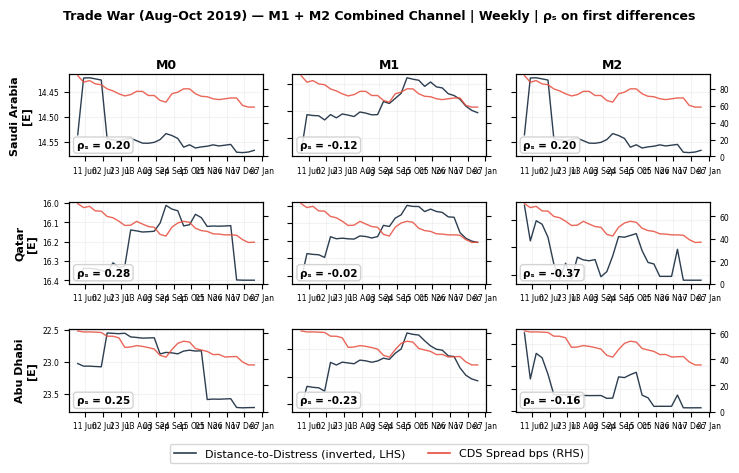

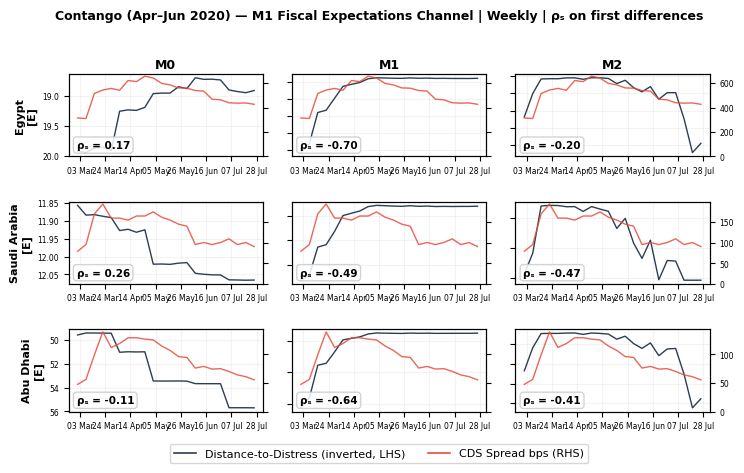

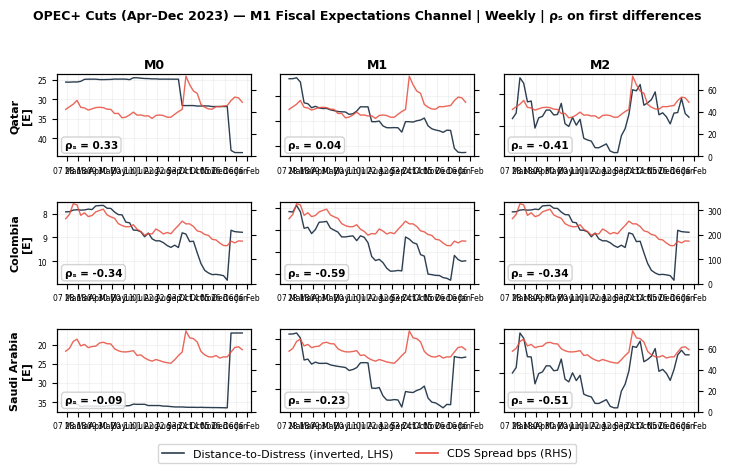

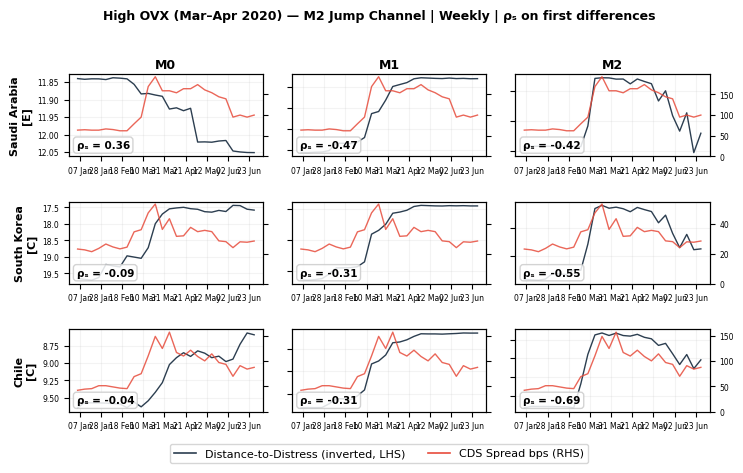

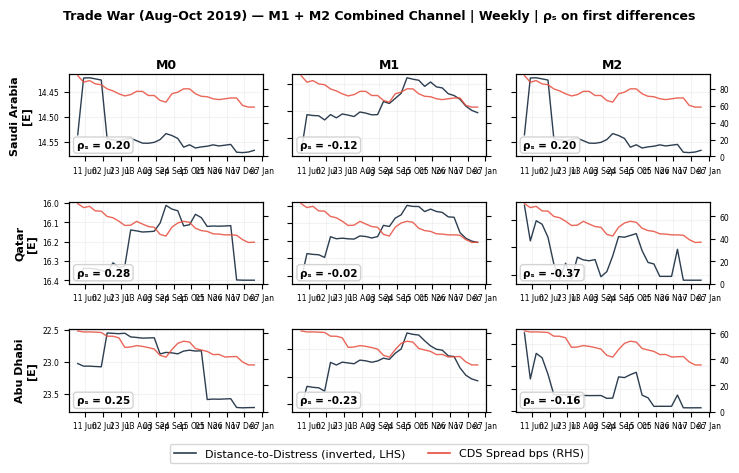

In [52]:
A4_W, A4_H = 8.27, 11.69
def plot_episode_grid(models_dict, episode_countries, episode_label, 
                      start_date, end_date, save_path=None):
    """
    Same style as plot_group_grid but filtered to a date window.
    episode_countries: list of (country, group_label) tuples
    """
    model_names = list(models_dict.keys())
    nrows = len(episode_countries)
    ncols = len(model_names)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(A4_W, A4_H * (nrows / 8)),
        gridspec_kw={'hspace': 0.55, 'wspace': 0.15}
    )

    if nrows == 1:
        axes = [axes]

    for row, (country, grp_label) in enumerate(episode_countries):
        for col, mname in enumerate(model_names):
            ax1 = axes[row][col]
            ax2 = ax1.twinx()

            d = (models_dict[mname][models_dict[mname]['country'] == country]
                 .sort_values('date').copy())
            d['date'] = pd.to_datetime(d['date'])

            # Filter to episode window
            d = (d[(d['date'] >= start_date) & (d['date'] <= end_date)]
                 .set_index('date')
                 .resample('W').last()
                 .reset_index())

            if d.empty or len(d) < 5:
                ax1.text(0.5, 0.5, 'No data', ha='center', va='center',
                         transform=ax1.transAxes, fontsize=8)
                continue

            ax1.plot(d['date'], d['distance_to_distress'],
                     color='#2C3E50', lw=1.0)
            ax2.plot(d['date'], d['cds_spread'],
                     color='#E74C3C', lw=1.0, alpha=0.85)
            ax2.set_ylim(bottom=0)
            ax1.invert_yaxis()

            ax1.tick_params(labelsize=5.5)
            ax2.tick_params(labelsize=5.5)
            ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
            ax1.grid(True, alpha=0.15)

            # Country label on left
            if col == 0:
                ax1.set_ylabel(f'{country}\n[{grp_label}]',
                               fontsize=8, fontweight='bold', labelpad=4)
            else:
                ax1.set_yticklabels([])

            # Model label on top
            if row == 0:
                ax1.set_title(mname, fontsize=9, fontweight='bold', pad=4)

            # Hide right-axis ticks except last column
            if col < ncols - 1:
                ax2.set_yticklabels([])

            # Spearman rho on first differences
            valid = d.dropna(subset=['distance_to_distress', 'cds_spread'])
            if len(valid) > 5:
                diffs = valid[['distance_to_distress', 
                               'cds_spread']].diff().dropna()
                rho, _ = spearmanr(diffs['distance_to_distress'],
                                   diffs['cds_spread'])
                ax1.text(
                    0.04, 0.10, f'ρₛ = {rho:.2f}',
                    transform=ax1.transAxes,
                    fontsize=7.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='#cccccc', alpha=0.85)
                )

    # Legend
    dd_line  = plt.Line2D([0], [0], color='#2C3E50', lw=1.2)
    cds_line = plt.Line2D([0], [0], color='#E74C3C', lw=1.2)
    fig.legend(
        [dd_line, cds_line],
        ['Distance-to-Distress (inverted, LHS)', 'CDS Spread bps (RHS)'],
        loc='lower center', ncol=2, fontsize=8,
        bbox_to_anchor=(0.5, -0.02),
        frameon=True, edgecolor='#cccccc'
    )
    fig.text(
        0.5, 1.005,
        f'{episode_label} | Weekly | ρₛ on first differences',
        ha='center', fontsize=9, fontweight='bold'
    )

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight', format='pdf')
        print(f'Saved: {save_path}')
    return fig


# ── Run for four episodes ──────────────────────────────────────

# Episode 1: Contango Apr-Jun 2020 — M1 channel
plot_episode_grid(
    dfs,
    [('Egypt', 'E'), ('Saudi Arabia', 'E'), ('Abu Dhabi', 'E')],
    episode_label='Contango (Apr–Jun 2020) — M1 Fiscal Expectations Channel',
    start_date='2020-03-01',
    end_date='2020-07-31',
    save_path='../output/figures/episode_contango_2020.pdf'
)

# Episode 2: OPEC+ Cuts Apr-Dec 2023 — M1 channel
plot_episode_grid(
    dfs,
    [('Qatar', 'E'), ('Colombia', 'E'), ('Saudi Arabia', 'E')],
    episode_label='OPEC+ Cuts (Apr–Dec 2023) — M1 Fiscal Expectations Channel',
    start_date='2023-03-01',
    end_date='2024-01-31',
    save_path='../output/figures/episode_opec_cuts_2023.pdf'
)

# Episode 3: High OVX Mar-Apr 2020 — M2 channel
plot_episode_grid(
    dfs,
    [('Saudi Arabia', 'E'), ('South Korea', 'C'), ('Chile', 'C')],
    episode_label='High OVX (Mar–Apr 2020) — M2 Jump Channel',
    start_date='2020-01-01',
    end_date='2020-06-30',
    save_path='../output/figures/episode_high_ovx_2020.pdf'
)

# Episode 4: Trade War Aug-Oct 2019 — M1 + M2 channel
plot_episode_grid(
    dfs,
    [('Saudi Arabia', 'E'), ('Qatar', 'E'), ('Abu Dhabi', 'E')],
    episode_label='Trade War (Aug–Oct 2019) — M1 + M2 Combined Channel',
    start_date='2019-06-01',
    end_date='2019-12-31',
    save_path='../output/figures/episode_trade_war_2019.pdf'
)